# Part 3: Creating the model and evaluation metrics
Here we will create our models with data from parts 1 and 2.

In [80]:
#Imports
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

#Our dataframe
final_df = pd.read_csv("cleaned_data/cleaned_df_final_test.csv") #TEMP NAME, remember to change.
#Variables that we need

## 3.1 Splitting training data for evaluation
To get some metrics of model performance, we will split our data so that we can verify the model is working well, without having to submit to kaggle every time.

In [81]:
#Define what proportion should be reserved for verifying. Evaluation will be done with the latter part.
SPLIT_RATIO = 0.975

#Find what day this corresponds to
split_day_numerical = final_df["days_normalized"].quantile(SPLIT_RATIO)
print("Splitting at ", SPLIT_RATIO, ", Corresponds to day", split_day_numerical)

#Split data according to our index
train_df = final_df[final_df["days_normalized"] <= split_day_numerical]
validation_df = final_df[final_df["days_normalized"] > split_day_numerical]

#Verify the split
print(f"Train range: {train_df['days_normalized'].min()} to {train_df['days_normalized'].max()}")
print(f"Test range: {validation_df['days_normalized'].min()} to {validation_df['days_normalized'].max()}")

first_test_date = validation_df["date_str"].iloc[0]
last_test_date = validation_df["date_str"].iloc[-1]
print("The data used for verifying starts at ", first_test_date, ", and ends at ", last_test_date)



Splitting at  0.975 , Corresponds to day 7305.0
Train range: 0 to 7305
Test range: 7306 to 7492
The data used for verifying starts at  2024-06-16 , and ends at  2024-12-19


## 3.2 Initializing the model
Here we initialize our models and select what columns will be used

In [4]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1
)
#xgb_model = xgb.XGBRegressor(obj='quantile', alpha = '0.2')
#xgb_model = xgb.XGBRegressor(obj = custom_objective)




#Select columns to use:
#xgb_X_columns = ["day_of_week","is_weekend","month","is_holiday","rolling_7","rolling_30","rolling_100"]
#We should limit rolling 7 and rolling 30
xgb_X_columns = ["day_of_week","is_weekend","month","is_holiday","rolling_100","rolling_300","rolling_600","shifted_200_rolling_30"]

## 3.3 Run test model with train and test split.
xgb fit does internal cross-validation in order to verify its result. Since our data is very time-dependant it makes sense to split our training data further, so that only late data is used for validating.

For now, this is the always the latest entries, but it would perhaps be more robust to take random samples for a range of late entries.

Splitting at  0.975 , Corresponds to day 6438.0
Train range: 0 to 6603
Test range: 6439 to 6603


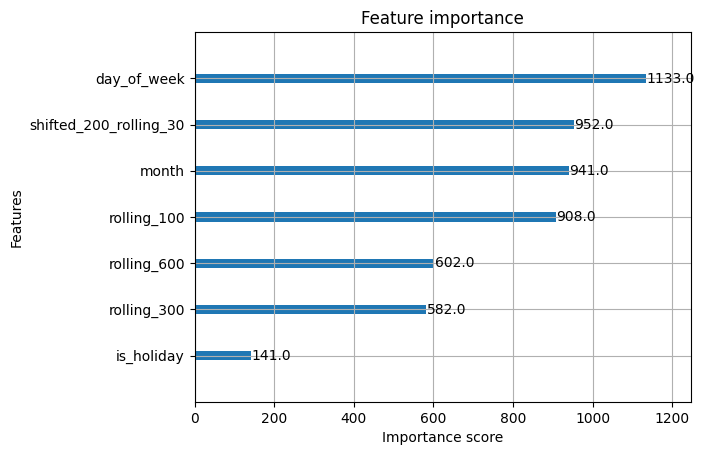

In [12]:
# We split again, and only choose the columsn we have selected for features.
split_day_numerical = train_df["days_normalized"].quantile(SPLIT_RATIO)
print("Splitting at ", SPLIT_RATIO, ", Corresponds to day", split_day_numerical)
train_df2 = train_df[train_df["days_normalized"] <= split_day_numerical] #Ugly name, but this is the training portion of the portion we reserved for training.
eval_df = train_df[train_df["days_normalized"] > split_day_numerical]

X_train = train_df2[xgb_X_columns]
y_train = train_df2["daily_weight"]

X_eval = eval_df[xgb_X_columns]
y_eval = eval_df["daily_weight"]

print(f"Train range: {train_df['days_normalized'].min()} to {train_df['days_normalized'].max()}")
print(f"Test range: {eval_df['days_normalized'].min()} to {eval_df['days_normalized'].max()}")


#dtrain = xgb.DMatrix(train_X, label=train_y)
#test_map = test_df
#test_y = test_df["daily_weight"]

xgb_model.fit(X_train, y_train, eval_set=[(X_eval, y_eval)], verbose=False)
#xgb_model = xgb.train(params, dtrain, num_boost_round=100)
#xgb_model = xgb.train(params, dtrain, num_boost_round=100, obj=quantile_objective())
xgb.plot_importance(xgb_model)
plt.show()


## 3.4: Preparing dataset we will pass to our predict() function.
Temporal values such as day_of_week are known up front and can be filled in.

Shifted_200 can also be filled in beforehand

For rolling averages we will use the latest available values instead. 
- TODO consider training on latest-values for rolling averages as well.

These are the "Common" features first.

In [ ]:

#When re-doing this for the full dataset, re-calibrate these dates.
first_prediction_date = pd.Timestamp(year=2024, month=6, day=16)
last_historical_date = pd.Timestamp(year=2024, month=6, day=15)
last_prediction_date = pd.Timestamp(year=2024, month = 12, day = 19)

#We create the window for which we will make our predictions.
prediction_date_range = pd.date_range(start=first_prediction_date, end=last_prediction_date)

#We only have to create one dataframe with the "common" variables, then we can predict in a loop and append those predictions to a new dataframe that should match the structure we want.

#We follow the same procedure as last section
#Add time-series data
test_map_df = pd.DataFrame({"date" : prediction_date_range})
test_map_df["day_of_week"] = test_map_df["date"].dt.dayofweek
test_map_df["is_weekend"]  = test_map_df['day_of_week'].isin([5, 6])
test_map_df["is_weekend"] = test_map_df["is_weekend"].astype(int)
test_map_df["month"] = test_map_df["date"].dt.month

#Add holidays
import holidays
years = list(range(2023, 2025))
all_holidays = holidays.Norway(years = years)
test_map_df["date_str"] = test_map_df["date"].dt.strftime('%Y-%m-%d')
holiday_str = set(pd.to_datetime(list(all_holidays.keys())).strftime('%Y-%m-%d'))
test_map_df["is_holiday"] = test_map_df["date_str"].isin(holiday_str)
test_map_df["is_holiday"] = test_map_df["is_holiday"].astype(int)

valid_ids = final_df["rm_id"].unique()

test_map_common = pd.concat([test_map_df] * len(valid_ids), ignore_index=True)
test_map_common["rm_id"] = np.repeat(valid_ids, len(test_map_df))

test_map_common["date_str"] = test_map_common["date"].dt.strftime('%Y-%m-%d')


187
37961


We create a loop for the "per-id" features.

Must run the snippet before this! Breaks if we only to the one below several times.

In [ ]:
latest_rollings = train_df.groupby("rm_id", sort=False)[["rolling_600", "rolling_300", "rolling_100"]].last().reset_index()
test_map_common = test_map_common.merge(latest_rollings, on="rm_id", how="left")
print(len(test_map_common))

days_to_subtract = timedelta(days = 200)
date200prior = first_prediction_date - days_to_subtract
range200prior = pd.date_range(start=date200prior, end=last_historical_date)
range200after = range200prior + days_to_subtract


range200prior_str = [d.strftime("%Y-%m-%d") for d in range200prior]


filtered_shifted = train_df[train_df["date_str"].isin(range200prior_str)][["rm_id", "date_str", "shifted_200_rolling_30"]]
filtered_shifted["date_after"] = range200after
test_map_common = test_map_common.merge(filtered_shifted, on = ["rm_id", "date_after"], how = "left")

#Verify that these match:
print(train_df["date_str"].tail().to_list())
print(range200prior_str[-5:])
#And that we get any matches
print(len(filtered_shifted))
#print(test_map_common.info())

print(test_map_common["date_str"].iloc[-5:])
print(type(test_map_common["date_str"].iloc[0]))
print("---------")
print(filtered_shifted["date_str"].iloc[-5:])
print(type(filtered_shifted["date_str"].iloc[0]))
print("============")
print(test_map_common["shifted_200_rolling_30"].tail())


37961
['2024-06-11', '2024-06-12', '2024-06-13', '2024-06-14', '2024-06-15']
['2024-06-11', '2024-06-12', '2024-06-13', '2024-06-14', '2024-06-15']
40600
37956    2024-12-15
37957    2024-12-16
37958    2024-12-17
37959    2024-12-18
37960    2024-12-19
Name: date_str, dtype: object
<class 'str'>
---------
1520887    2024-06-11
1520888    2024-06-12
1520889    2024-06-13
1520890    2024-06-14
1520891    2024-06-15
Name: date_str, dtype: object
<class 'str'>
37956   NaN
37957   NaN
37958   NaN
37959   NaN
37960   NaN
Name: shifted_200_rolling_30, dtype: float64


In [85]:

test_map_common.to_csv("test_predictions/test_map.csv", index=False)

In [ ]:


all_test_predictions = []
valid_ids = final_df["rm_id"].unique()

for id, group in full_test_map.groupby("rm_id", sort=False):
    group = group.sort_values('date').copy()
    predictions = []
    predictions.extend(get_prior100_weights(train_df, id))
    rolling_7s = []
    rolling_30s = []
    rolling_100s = []

    for i in range(len(group)): #len(group)
        current_row = group.iloc[i].copy()
        
        previous_preds = pd.Series(predictions)
        current_row['rolling_7'] = previous_preds.rolling(window = 7).mean().iloc[-1]
        current_row['rolling_30'] = previous_preds.rolling(window = 30).mean().iloc[-1]
        current_row['rolling_100'] = previous_preds.rolling(window = 100).mean().iloc[-1]

        X_current = current_row[xgb_X_columns].values.reshape(1, -1)
        #dcurrent = xgb.DMatrix(X_current, feature_names=xgb_X_columns)
        if xgb_model.predict(X_current)[0] > 5:
            y_pred = xgb_model.predict(X_current)[0]
        else:
            y_pred = 0
        predictions.append(y_pred)
        rolling_7s.append(current_row["rolling_7"])
        rolling_30s.append(current_row["rolling_30"])
        rolling_100s.append(current_row["rolling_100"])

    print(id)

    group['predicted_weight'] = predictions[100:]
    group['rm_id'] = id
    group['rolling_7'] = rolling_7s
    group['rolling_30'] = rolling_30s
    group['rolling_100'] = rolling_100s

    all_test_predictions.append(group)

test_prediction_df = pd.concat(all_test_predictions)
#Make csv to observe data
test_prediction_df.to_csv("test_predictions/test_predictions_new.csv", index=False)

365
379
389
369
366
367
375
388
368
347
357
378
342
346
364
381
354
383
360
386
345
348
358
374
353
390
380
387
1845
343
1903
1909
1902
1907
1906
1901
1904
362
1908
1905
1873
1876
1851
1871
1875
1874
1844
1882
1866
1982
1981
1872
2061
2001
1843
1854
1842
1853
1868
1852
1857
1850
1867
1846
2102
1858
2131
2160
2132
2145
2146
2140
2141
2143
2142
2157
2130
2135
2152
2151
2155
2134
2149
2144
2150
2125
2153
2127
2124
2133
2156
2159
2148
2128
2138
2161
2139
2123
2182
2147
2201
2223
2222
2261
2129
2121
2122
2284
2285
2304
2364
2365
2322
2283
2282
2323
2302
2341
2343
2344
2345
2347
2348
2363
2158
2362
2401
2402
2421
2441
2481
2482
2521
2561
2601
355
2741
2742
2761
2821
2841
2861
2981
3005
3022
3101
3123
3122
3126
3124
3142
3144
3121
3125
3162
3161
3222
3201
3241
3265
3282
3362
3421
3441
3481
3501
3381
3541
3642
3621
3601
3761
3781
3701
3802
3821
3841
3865
3762
3883
3901
3941
3581
4021
3921
4044
4081
4101
4161
4222
4263
4302
4343
4381
4401
4443
3461
4441
4462
4463
4461
4481
4501


### 3.3 test performances.
For making adjustments we can display some performance metrics now, but we will need to evaluate performance in next section (post-prediction-cleanup)

In [15]:
test_prediction_df["rm_id"] = pd.Categorical(test_prediction_df["rm_id"], categories=valid_ids, ordered=False)
y_pred = test_prediction_df["predicted_weight"]


mse = mean_squared_error(test_y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, y_pred)
r2 = r2_score(test_y, y_pred)


print(f'Mean squared Error: {mse:.4f}')
print(f'Root Mean Squared: {rmse:.4f}')
print(f'Mean absolute error: {mae:.4f}')
print(f'r2-score: {r2:.4f}')


#Best so far:
""" Mean squared Error: 18866094.3280
Root Mean Squared: 4343.5118
Mean absolute error: 793.8375
r2-score: 0.7197 """



Mean squared Error: 39036032.4466
Root Mean Squared: 6247.8822
Mean absolute error: 1126.9892
r2-score: 0.4199


' Mean squared Error: 18866094.3280\nRoot Mean Squared: 4343.5118\nMean absolute error: 793.8375\nr2-score: 0.7197 '

# 3.4 Create dataframe for prediction window
test split already has data such as day_of_week, month, holidays etc. We must prepare our prediction window (from 1st Jan 2025 to 31st May) to also hold these values so they can be used for prediction.

In [ ]:


first_prediction_date = pd.Timestamp(year=2025, month=1, day=1)
last_historical_date = pd.Timestamp(year=2024, month=12, day=20) #Last historical data ends at 19 december 2024. We might want to predict from this date then remove first entries.
last_prediction_date = pd.Timestamp(year=2025, month = 5, day = 31)

#We create the window for which we will make our predictions.
prediction_date_range = pd.date_range(start=last_historical_date, end=last_prediction_date)

#We only have to create one dataframe with the "common" variables, then we can predict in a loop and append those predictions to a new dataframe that should match the structure we want.

#We follow the same procedure as last section
#Add time-series data
prediction_map_df = pd.DataFrame({"date" : prediction_date_range})
prediction_map_df["day_of_week"] = prediction_map_df["date"].dt.dayofweek
prediction_map_df["is_weekend"]  = prediction_map_df['day_of_week'].isin([5, 6])
prediction_map_df["is_weekend"] = prediction_map_df["is_weekend"].astype(int)
prediction_map_df["month"] = prediction_map_df["date"].dt.month

#Add holidays
import holidays
years = list(range(2024, 2026))
all_holidays = holidays.Norway(years = years)
prediction_map_df["date_str"] = prediction_map_df["date"].dt.strftime('%Y-%m-%d')
holiday_str = set(pd.to_datetime(list(all_holidays.keys())).strftime('%Y-%m-%d'))
prediction_map_df["is_holiday"] = prediction_map_df["date_str"].isin(holiday_str)
prediction_map_df["is_holiday"] = prediction_map_df["is_holiday"].astype(int)

#Add empty columns for rolling windows
prediction_map_df["rolling_7"] = 0
prediction_map_df["rolling_30"] = 0
prediction_map_df["rolling_100"] = 0


valid_ids = final_df["rm_id"].unique()

full_pred_map = pd.concat([prediction_map_df] * len(valid_ids), ignore_index=True)
full_pred_map["rm_id"] = np.repeat(valid_ids, len(prediction_map_df))






Run the code below to make predictions for the whole data. Note that this will override the all_predictions name from the test code.

In [ ]:
train_X_full = final_df[xgb_X_columns]
train_y_full = final_df["daily_weight"]

xgb_model.fit(train_X_full, train_y_full)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [63]:
#For test_data we can use what we have.

all_predictions = []
valid_ids = final_df["rm_id"].unique()

for id, group in full_pred_map.groupby("rm_id", sort=False):
    group = group.sort_values('date').copy()
    predictions = []
    predictions.extend(get_prior100_weights(final_df, id))
    rolling_7s = []
    rolling_30s = []
    rolling_100s = []

    for i in range(len(group)): #len(group)
        current_row = group.iloc[i].copy()
        
        previous_preds = pd.Series(predictions)
        current_row['rolling_7'] = previous_preds.rolling(window = 7).mean().iloc[-1]
        current_row['rolling_30'] = previous_preds.rolling(window = 30).mean().iloc[-1]
        current_row['rolling_100'] = previous_preds.rolling(window = 100).mean().iloc[-1]

        X_current = current_row[xgb_X_columns].values.reshape(1, -1)
        print(current_row[xgb_X_columns])
        if xgb_model.predict(X_current)[0] > 5:
            y_pred = xgb_model.predict(X_current)[0]
        else:
            y_pred = 0
        predictions.append(y_pred)
        rolling_7s.append(current_row["rolling_7"])
        rolling_30s.append(current_row["rolling_30"])
        rolling_100s.append(current_row["rolling_100"])

    group['predicted_weight'] = predictions[100:]
    group['rm_id'] = id
    group['rolling_7'] = rolling_7s
    group['rolling_30'] = rolling_30s
    group['rolling_100'] = rolling_100s

    all_predictions.append(group)

prediction_df = pd.concat(all_predictions)
#Make csv to observe data
prediction_df.to_csv("raw_predictions.csv", index=False)

day_of_week      4
is_weekend       0
month           12
is_holiday       0
rolling_7      0.0
rolling_30     0.0
rolling_100    0.0
Name: 0, dtype: object
day_of_week      5
is_weekend       1
month           12
is_holiday       0
rolling_7      0.0
rolling_30     0.0
rolling_100    0.0
Name: 1, dtype: object
day_of_week      6
is_weekend       1
month           12
is_holiday       0
rolling_7      0.0
rolling_30     0.0
rolling_100    0.0
Name: 2, dtype: object
day_of_week      0
is_weekend       0
month           12
is_holiday       0
rolling_7      0.0
rolling_30     0.0
rolling_100    0.0
Name: 3, dtype: object
day_of_week      1
is_weekend       0
month           12
is_holiday       0
rolling_7      0.0
rolling_30     0.0
rolling_100    0.0
Name: 4, dtype: object
day_of_week      2
is_weekend       0
month           12
is_holiday       1
rolling_7      0.0
rolling_30     0.0
rolling_100    0.0
Name: 5, dtype: object
day_of_week      3
is_weekend       0
month           12
is_holi

In [ ]:
prediction_df["rm_id"] = pd.Categorical(prediction_df["rm_id"], categories=valid_ids, ordered=False)
y_pred = prediction_df["predicted_weight"]
#y_actual = final_df["daily_weight"]

mse = mean_squared_error(test_y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, y_pred)
r2 = r2_score(test_y, y_pred)


print(f'Mean squared Error: {mse:.4f}')
print(f'Root Mean Squared: {rmse:.4f}')
print(f'Mean absolute error: {mae:.4f}')
print(f'r2-score: {r2:.4f}')


<bound method NDFrame.to_csv of             date  day_of_week  is_weekend  month    date_str  is_holiday  \
0     2024-12-20            4           0     12  2024-12-20           0   
1     2024-12-21            5           1     12  2024-12-21           0   
2     2024-12-22            6           1     12  2024-12-22           0   
3     2024-12-23            0           0     12  2024-12-23           0   
4     2024-12-24            1           0     12  2024-12-24           0   
...          ...          ...         ...    ...         ...         ...   
33084 2025-05-27            1           0      5  2025-05-27           0   
33085 2025-05-28            2           0      5  2025-05-28           0   
33086 2025-05-29            3           0      5  2025-05-29           1   
33087 2025-05-30            4           0      5  2025-05-30           0   
33088 2025-05-31            5           1      5  2025-05-31           0   

       rolling_7  rolling_30  rolling_100  rm_id  predi

In [ ]:

#Make csv to observe data
prediction_df.to_csv("test_predictions.csv", index=False)

In [ ]:
print(final_df["daily_weight"].mean())
print(final_df["daily_weight]"].var())

## 3.3.2 OPTION 2- USE ALL DATA
for actual submissions

### Preparing prediction window.
To make it easier when we make predictions, we will add all features we can to the prediction window.



